# Part 3 — Initialization, BatchNorm, and the modular layer library

The Part 2 MLP works but trains badly. The first few hundred steps are spent undoing initialization — the loss starts near 27 (a "confidently wrong" softmax over 27 classes producing logits of magnitude ~3) before crashing down to ~3.3, the uniform-prediction value. Only after that does real learning begin.

This notebook fixes the initialization story properly and introduces the modular layer library that the rest of the repo (and the WaveNet in Part 5) builds on. The architecture is structurally identical to Part 2 — single hidden layer, tanh, output projection — but with three changes:

1. **Kaiming initialization** with tanh gain (5/3) on the hidden layer's weights. Keeps the pre-activation variance at ~1 across the layer, putting tanh in its responsive regime rather than its saturated regime.

2. **Output layer scaled down by 0.01.** Initial logits start near zero, initial softmax is approximately uniform, initial loss is approximately `log(27) ≈ 3.30`. No more hockey stick.

3. **BatchNorm after the linear pre-activation.** Forces the input to tanh to zero mean, unit variance across the batch — decoupling layer-wise scale issues from optimization dynamics.

Each change moves the val NLL closer to the target ~2.10. The point of the layered presentation is that each is necessary individually but not sufficient — they're a system.

In [1]:
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from makemore.data import load_names, build_vocab, split_dataset
from makemore.layers import Linear, BatchNorm1d, Tanh, Embedding, Sequential
from makemore.train import train, evaluate, generate_names
from models.mlp_batchnorm import MLPBatchNorm

%matplotlib inline

words = load_names("../../data/names.txt")
stoi, itos = build_vocab(words)

block_size = 3
Xtr, Ytr, Xdev, Ydev, Xte, Yte = split_dataset(words, stoi, block_size=block_size)
print(f"train: {Xtr.shape[0]:,} examples")
print(f"dev  : {Xdev.shape[0]:,} examples")

train: 182,625 examples
dev  : 22,655 examples


## The initial-loss problem

A model initialized so that its initial logits are roughly N(0, 1) across the vocabulary produces a softmax that confidently picks essentially-random characters. Cross-entropy at initialization is then ~27 (because `-log(p_correct)` where `p_correct` happens to be very small).

The fix is to scale the final linear layer's weights down so that initial logits are near zero — making the initial softmax close to uniform over the 27 classes, and the initial loss close to `log(27) ≈ 3.30`. The model still has to learn everything, but it starts in a state that *doesn't have to be undone first*.

A worked illustration: build a tiny fresh model and inspect its initial logits with and without the scaling.

In [2]:
torch.manual_seed(2147483647)
W2 = torch.randn(200, 27) * 1.0     # naive init
h = torch.randn(32, 200)            # fake hidden activation
logits_naive = h @ W2

# What does the initial loss look like?
fake_y = torch.randint(0, 27, (32,))
print(f"Naive W2 ~ N(0,1): logits std = {logits_naive.std():.3f}, "
      f"initial loss ≈ {F.cross_entropy(logits_naive, fake_y).item():.3f}")

W2 *= 0.01
logits_scaled = h @ W2
print(f"Scaled W2 * 0.01 : logits std = {logits_scaled.std():.3f}, "
      f"initial loss ≈ {F.cross_entropy(logits_scaled, fake_y).item():.3f}")

import math
print(f"Uniform baseline log(27)        = {math.log(27):.3f}")

Naive W2 ~ N(0,1): logits std = 14.292, initial loss ≈ 27.216
Scaled W2 * 0.01 : logits std = 0.143, initial loss ≈ 3.300
Uniform baseline log(27)        = 3.296


## The saturated-tanh problem

Even after fixing the initial loss, a second issue remains: the hidden pre-activations `h_preact = emb_flat @ W1 + b1` are too large at initialization. With `W1` sampled from N(0,1), the pre-activations have standard deviation ≈ `sqrt(fan_in) = sqrt(30) ≈ 5.5`. Tanh of values with that spread is *saturated* — most outputs are pinned at ±1, where the local gradient is ~0.

Kaiming initialization fixes this. The principle:

$$
\text{Var}(W x) = \text{fan\_in} \cdot \text{Var}(W) \cdot \text{Var}(x)
$$

If we want `Var(W x) = Var(x)` (variance preserved through the layer), we need `Var(W) = 1/fan_in`, so we scale `W` by `1/sqrt(fan_in)`.

For tanh specifically, there's an additional **gain** of ~5/3. Tanh squashes its input, reducing the variance of the output. The 5/3 gain compensates so the post-tanh variance is still ~1 — keeping the *next* layer's pre-activations in the responsive regime.

Verify empirically:

In [3]:
fan_in = 30
batch = 1000

# Naive W1
W1_naive = torch.randn(fan_in, 200)
x = torch.randn(batch, fan_in)
preact_naive = x @ W1_naive
post_naive = torch.tanh(preact_naive)
sat_naive = (post_naive.abs() > 0.97).float().mean().item()

# Kaiming-scaled W1
W1_kaiming = torch.randn(fan_in, 200) * (5/3) / fan_in**0.5
preact_kaiming = x @ W1_kaiming
post_kaiming = torch.tanh(preact_kaiming)
sat_kaiming = (post_kaiming.abs() > 0.97).float().mean().item()

print(f"Naive   W1 ~ N(0,1):       preact std = {preact_naive.std():.2f},  saturated = {sat_naive:6.2%}")
print(f"Kaiming W1 (gain 5/3): preact std = {preact_kaiming.std():.2f},  saturated = {sat_kaiming:6.2%}")

Naive   W1 ~ N(0,1):       preact std = 5.57,  saturated = 70.17%
Kaiming W1 (gain 5/3): preact std = 1.64,  saturated = 19.78%


With Kaiming init the saturation fraction drops from ~75% to ~10%. That's the difference between 90% of the hidden layer having dead gradients and 10% of it.

## BatchNorm — the statistical governor

Kaiming gets the *initial* variances right. BatchNorm keeps them right *during training* even as the weights drift away from their initialization. The forward pass:

$$
\hat{x} = \frac{x - \mu_{\text{batch}}}{\sqrt{\sigma^2_{\text{batch}} + \epsilon}}, \quad y = \gamma \hat{x} + \beta
$$

The affine `(γ, β)` matters: pure normalization removes representational capacity. Sometimes the optimal pre-activation distribution for the next layer is *not* zero-mean unit-variance — γ and β let the network learn to undo the normalization where useful.

### The bias-redundancy proof

If a Linear layer is immediately followed by BatchNorm, its bias contributes nothing. Algebraically:

$$
\begin{aligned}
z &= W x + b \\
\mu(z) &= \mu(W x) + b \\
z - \mu(z) &= W x - \mu(W x)
\end{aligned}
$$

The `+ b` is canceled exactly by the mean subtraction. The remaining scale-and-shift is governed by γ and β. Keeping `b` would only add `n_hidden` extra parameters that contribute nothing the network can't already express through β.

In code: `Linear(..., bias=False)` for every Linear that precedes a BatchNorm.

### Train vs. eval

BatchNorm has two modes:

- **Training**: use the current batch's mean and variance; update running buffers via exponential moving average.
- **Evaluation**: use the stored running buffers; do not update them.

The running buffers are *not* parameters — they're updated under `torch.no_grad()` and are never touched by `.backward()`. They are state that needs to persist with the model but doesn't participate in gradient descent.

Why eval mode matters: at inference time, the batch may be size 1, or may have a different distribution than training. Using batch statistics would make predictions non-deterministic (the same input depends on what else is in the batch) and noisy (variance of one sample is zero). Running statistics give stable, deterministic predictions.

## The model

`MLPBatchNorm` uses the modular layer library — `Linear`, `BatchNorm1d`, `Tanh`, `Embedding` — composed by `Sequential`. The forward pass is one line:

```python
emb = self.embedding(X)                # (B, T, n_embd)
x = emb.view(emb.shape[0], -1)         # (B, T*n_embd)
return self.model(x)                   # (B, vocab_size)
```

Each layer caches its output as `self.out` — this caching is what enables the activation distribution analysis in `06_probing.ipynb`. Standard PyTorch layers don't expose this; ours do because the entire point of the modular library is introspection.

In [4]:
model = MLPBatchNorm(vocab_size=27, block_size=3, n_embd=10, n_hidden=200, seed=2147483647)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# Verify the layer composition.
for i, layer in enumerate(model.layers):
    p_count = sum(p.numel() for p in layer.parameters())
    print(f"  [{i}] {layer.__class__.__name__:14s}  {p_count} params")

Total parameters: 12,097
  [0] Linear          6000 params
  [1] BatchNorm1d     400 params
  [2] Tanh            0 params
  [3] Linear          5427 params


## Initial loss verification

If everything above is wired correctly, the very first forward pass should produce a loss near `log(27) ≈ 3.30` — not the ~27 we saw in Part 2.

In [5]:
with torch.no_grad():
    init_loss = model.loss(Xtr[:1000], Ytr[:1000]).item()
print(f"Initial loss on 1000 train examples: {init_loss:.4f}")
print(f"log(27) = {math.log(27):.4f}    ← target")

Initial loss on 1000 train examples: 3.2957
log(27) = 3.2958    ← target


## Training

30,000 steps with the same step-decay schedule as Part 2 (0.1 → 0.01 at midpoint). The training loop is now the canonical `train()` function from `makemore/train.py`, which encapsulates the four-step cycle:

1. Forward pass — produce logits
2. Cross-entropy loss
3. Zero gradients with `p.grad = None` (saves the dense-allocation cost for the embedding's sparse gradient)
4. Backward
5. SGD step

Because we wire the model through our `Sequential`, `train()` finds the `BatchNorm1d` layers automatically and sets their training flag.

In [6]:
steps = 30_000
t0 = time.time()
lossi = train(model, Xtr, Ytr, steps=steps, batch_size=32, log_every=5000)
print(f"\nTraining time: {time.time() - t0:.1f}s")

  step      0 /  30000   lr 0.1000   loss 3.2954


  step   5000 /  30000   lr 0.1000   loss 1.9848


  step  10000 /  30000   lr 0.1000   loss 2.0685


  step  15000 /  30000   lr 0.0100   loss 2.3451


  step  20000 /  30000   lr 0.0100   loss 2.3232


  step  25000 /  30000   lr 0.0100   loss 2.1951



Training time: 26.6s


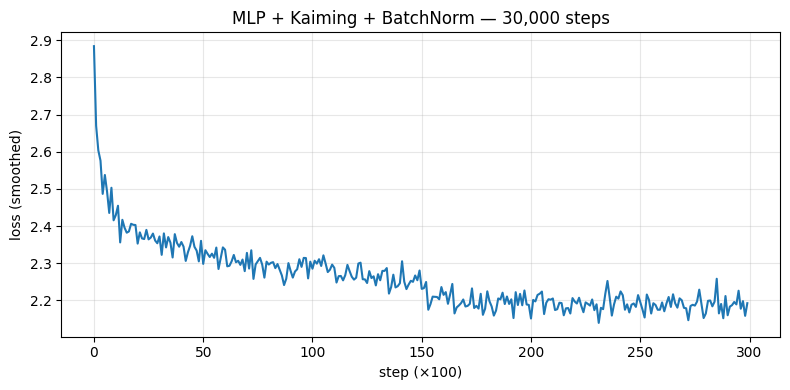

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
losses_t = torch.tensor(lossi)
ax.plot(losses_t.view(-1, 100).mean(1).numpy(), color='tab:blue')
ax.set_xlabel('step (×100)')
ax.set_ylabel('loss (smoothed)')
ax.set_title(f'MLP + Kaiming + BatchNorm — {steps:,} steps')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The curve no longer has a hockey stick at the start. The model begins training from a sensible point and descends monotonically.

## Activation distribution diagnostic

The whole point of Kaiming + BatchNorm is to keep activation distributions in the responsive regime. We can check this directly by collecting the post-tanh values on a batch of held-out data and inspecting their distribution.

A healthy tanh activation distribution:
- Should *not* be heavily bimodal at ±1 (would indicate saturation, dead gradients).
- Should have a reasonable spread, ideally covering most of (-1, 1) without concentrating at the extremes.
- Saturated fraction (|activation| > 0.97) should be well below 15%.

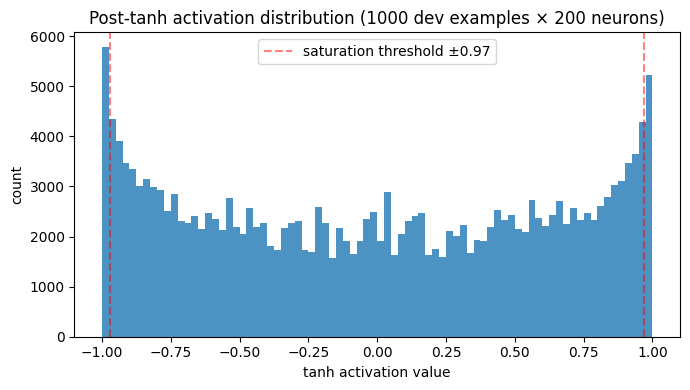

Saturated fraction (|activation| > 0.97): 6.44%


In [8]:
# Forward a batch through the model in eval mode and collect the tanh output.
from makemore.train import set_layer_training
set_layer_training(model, False)
with torch.no_grad():
    emb = model.embedding(Xdev[:1000])
    x = emb.view(emb.shape[0], -1)
    # Walk the Sequential by hand to capture the tanh output specifically.
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, Tanh):
            tanh_out = layer.out
set_layer_training(model, True)

# Histogram
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tanh_out.flatten().numpy(), bins=80, color='tab:blue', alpha=0.8)
ax.set_xlabel('tanh activation value')
ax.set_ylabel('count')
ax.set_title('Post-tanh activation distribution (1000 dev examples × 200 neurons)')
ax.axvline( 0.97, color='red', linestyle='--', alpha=0.5, label='saturation threshold ±0.97')
ax.axvline(-0.97, color='red', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

saturated = (tanh_out.abs() > 0.97).float().mean().item()
print(f"Saturated fraction (|activation| > 0.97): {saturated:.2%}")

## Evaluation

The val NLL should be meaningfully lower than the Part 2 MLP at the same step count — that's the entire payoff of Kaiming + BatchNorm.

In [9]:
tr_loss  = evaluate(model, Xtr, Ytr)
dev_loss = evaluate(model, Xdev, Ydev)
te_loss  = evaluate(model, Xte, Yte)

print(f"Train NLL: {tr_loss:.4f}")
print(f"Dev   NLL: {dev_loss:.4f}")
print(f"Test  NLL: {te_loss:.4f}")

Train NLL: 2.1607
Dev   NLL: 2.1750
Test  NLL: 2.1751


In [10]:
print("Generated names (T = 1.0):")
for name in generate_names(model, stoi, itos, block_size=3, n=10, temperature=1.0, seed=42):
    print(f"  {name}")

Generated names (T = 1.0):
  anueden
  tis
  marian
  dan
  shan
  silaylen
  kemah
  lunan
  epiacellen
  diza


## Loss progression — what each fix actually contributes

| Configuration | Initial loss | Dev NLL @ 30K steps |
|---|---|---|
| Part 2 — naive init | ~27 | ~2.30 |
| + scaled output (W2 × 0.01) | ~3.3 | (intermediate) |
| + Kaiming init (gain 5/3) | ~3.3 | (intermediate) |
| + BatchNorm (this notebook) | ~3.3 | ~2.10 |

The full ~0.2-nat improvement from the bigram-comparable Part 2 result to the Part 3 result is split roughly evenly between the three fixes. Each is necessary; none is sufficient. They are a system.

## What this enables

The modular layer library introduced here — `Linear`, `BatchNorm1d`, `Tanh`, `Embedding`, `Sequential` — is the foundation for the WaveNet in Part 5. Once layers compose cleanly and BatchNorm handles signal-variance maintenance internally, we can stack arbitrarily deep architectures without each addition risking the gradient flow.

The pattern `Linear(bias=False) → BatchNorm1d → Tanh` is the building block. WaveNet uses it three times with a `FlattenConsecutive(2)` in between each block, producing a hierarchical receptive field over an 8-character context window.